In [ ]:
# install required packages
import subprocess
import sys

def install_package(package):
    """Install a package using pip"""
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        return True
    except:
        return False
        
required_packages = ['pandas', 'numpy', 'matplotlib', 'seaborn']

print("Checking required packages...")
for package in required_packages:
    try:
        __import__(package)
        print(f"{package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        if install_package(package):
            print(f"{package} installed")
        else:
            print(f"Failed to install {package}")

print("Packages ready")

Checking required packages...
pandas already installed
numpy already installed
matplotlib already installed
seaborn already installed
Packages ready


## Package Installation

# Electric Vehicle Population Analysis

A comprehensive data analysis project exploring electric vehicle adoption trends, manufacturer distributions, and geographic patterns.

## Import Libraries

In [16]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported")

Libraries imported


## Load Dataset

In [ ]:
# Download dataset from Kaggle using direct API
import io
print("Downloading Electric Vehicle Population dataset from Kaggle...")

try:
    kaggle_url = "https://data.wa.gov/api/views/f6w7-q2d2/rows.csv?accessType=DOWNLOAD"
    
    import urllib.request
    response = urllib.request.urlopen(kaggle_url, timeout=30)
    csv_data = response.read().decode('utf-8')
    
    df = pd.read_csv(io.StringIO(csv_data))
    
    print(f"Dataset downloaded successfully")
    print(f"Total records: {len(df):,}")
    print(f"Total columns: {len(df.columns)}")
    
except Exception as e:
    print(f"Download failed: {str(e)[:100]}")
    print("\nCreating comprehensive sample Electric Vehicle dataset...")
    
    # Create realistic EV dataset
    sample_data = {
        'VIN (1-10)': ['WBY8P2C51K', 'JTDKARFP1J', '5YJSA1E27L', 'JTDKARFP4K', '5YJ3E1EA3K',
                      '1N4AZ0CP0F', '5YJSA1H20F', 'JTMAB3FV8N', '5YJ3E1EB7K', '1G1FW6S00H',
                      'KNDJX3AE8K', '5YJXCAE40G', 'JTDKARFP9K', 'WBY8P4C50K', '5YJ3E1EA8L'],
        'County': ['King', 'Snohomish', 'King', 'Pierce', 'King', 'King', 'Pierce', 'Snohomish',
                  'King', 'Clark', 'King', 'Pierce', 'King', 'Snohomish', 'King'],
        'City': ['Seattle', 'Bothell', 'Bellevue', 'Tacoma', 'Redmond', 'Seattle', 'Puyallup',
                'Everett', 'Kirkland', 'Vancouver', 'Sammamish', 'Lakewood', 'Seattle', 'Lynnwood', 'Bellevue'],
        'State': ['WA'] * 15,
        'Postal Code': [98102, 98011, 98004, 98402, 98052, 98103, 98371, 98201, 98033, 98661,
                       98074, 98499, 98115, 98087, 98005],
        'Model Year': [2019, 2018, 2023, 2019, 2019, 2016, 2015, 2022, 2019, 2020,
                      2020, 2017, 2019, 2020, 2023],
        'Make': ['BMW', 'TOYOTA', 'TESLA', 'TOYOTA', 'TESLA', 'NISSAN', 'TESLA', 'TOYOTA',
                'TESLA', 'CHEVROLET', 'KIA', 'TESLA', 'TOYOTA', 'BMW', 'TESLA'],
        'Model': ['I3', 'PRIUS PRIME', 'MODEL 3', 'PRIUS PRIME', 'MODEL 3', 'LEAF', 'MODEL S',
                 'RAV4 PRIME', 'MODEL 3', 'BOLT EV', 'NIRO EV', 'MODEL X', 'PRIUS PRIME', 'I3', 'MODEL 3'],
        'Electric Vehicle Type': ['Battery Electric Vehicle (BEV)', 'Plug-in Hybrid Electric Vehicle (PHEV)', 
                                 'Battery Electric Vehicle (BEV)', 'Plug-in Hybrid Electric Vehicle (PHEV)',
                                 'Battery Electric Vehicle (BEV)', 'Battery Electric Vehicle (BEV)',
                                 'Battery Electric Vehicle (BEV)', 'Plug-in Hybrid Electric Vehicle (PHEV)',
                                 'Battery Electric Vehicle (BEV)', 'Battery Electric Vehicle (BEV)',
                                 'Battery Electric Vehicle (BEV)', 'Battery Electric Vehicle (BEV)',
                                 'Plug-in Hybrid Electric Vehicle (PHEV)', 'Battery Electric Vehicle (BEV)',
                                 'Battery Electric Vehicle (BEV)'],
        'Clean Alternative Fuel Vehicle (CAFV) Eligibility': [
            'Clean Alternative Fuel Vehicle Eligible', 'Not eligible due to low battery range',
            'Eligibility unknown as battery range has not been researched', 'Not eligible due to low battery range',
            'Clean Alternative Fuel Vehicle Eligible', 'Clean Alternative Fuel Vehicle Eligible',
            'Clean Alternative Fuel Vehicle Eligible', 'Clean Alternative Fuel Vehicle Eligible',
            'Clean Alternative Fuel Vehicle Eligible', 'Clean Alternative Fuel Vehicle Eligible',
            'Clean Alternative Fuel Vehicle Eligible', 'Clean Alternative Fuel Vehicle Eligible',
            'Not eligible due to low battery range', 'Clean Alternative Fuel Vehicle Eligible',
            'Eligibility unknown as battery range has not been researched'],
        'Electric Range': [153, 25, 272, 25, 215, 107, 210, 42, 215, 238, 239, 289, 25, 153, 272],
        'Base MSRP': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        'Legislative District': [43, 1, 48, 27, 48, 46, 25, 38, 48, 18, 5, 29, 43, 21, 48],
        'DOL Vehicle ID': [206124966, 249861903, 142645324, 127716867, 265576765, 114578652,
                          198432651, 223145687, 245687123, 178945632, 256874123, 189456732,
                          234567891, 267891234, 145678923],
        'Vehicle Location': ['POINT (-122.32985 47.6357)', 'POINT (-122.20629 47.76063)', 
                           'POINT (-122.16265 47.62937)', 'POINT (-122.47625 47.23969)',
                           'POINT (-122.12289 47.66972)', 'POINT (-122.33945 47.65478)',
                           'POINT (-122.29287 47.16876)', 'POINT (-122.19821 47.97897)',
                           'POINT (-122.20761 47.67658)', 'POINT (-122.66565 45.63873)',
                           'POINT (-122.03585 47.61631)', 'POINT (-122.51845 47.16543)',
                           'POINT (-122.31456 47.66789)', 'POINT (-122.26543 47.82345)',
                           'POINT (-122.15678 47.61234)'],
        'Electric Utility': ['CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)', 
                           'PUGET SOUND ENERGY INC', 'PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)',
                           'PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)',
                           'PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)',
                           'CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)',
                           'PUGET SOUND ENERGY INC', 'PUGET SOUND ENERGY INC',
                           'PUGET SOUND ENERGY INC', 'CLARK PUBLIC UTILITIES (WA)',
                           'PUGET SOUND ENERGY INC', 'PUGET SOUND ENERGY INC',
                           'CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)',
                           'PUGET SOUND ENERGY INC', 'PUGET SOUND ENERGY INC'],
        '2020 Census Tract': [53033005301, 53061052115, 53033023403, 53053007300, 53033022604,
                             53033005201, 53053030700, 53061051802, 53033022502, 53011040504,
                             53033029405, 53053061800, 53033004800, 53061051301, 53033023502]
    }
    
    df_base = pd.DataFrame(sample_data)

    df_list = [df_base.copy()]
    for i in range(1, 50):
        df_copy = df_base.copy()
        df_copy['VIN (1-10)'] = df_copy['VIN (1-10)'].apply(lambda x: x[:-1] + str(i % 10))
        df_copy['DOL Vehicle ID'] = df_copy['DOL Vehicle ID'] + i * 1000
        df_list.append(df_copy)
    
    df = pd.concat(df_list, ignore_index=True)
    
    print(f"Sample dataset created with {len(df):,} records")
    print(f"Total records: {len(df):,}")
    print(f"Total columns: {len(df.columns)}")

print("First few rows:")
df.head()

Dataset downloaded successfully
Total records: 269,673
Total columns: 17
First few rows:
Dataset downloaded successfully
Total records: 269,673
Total columns: 17
First few rows:


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,3C3CFFGE1G,Yakima,Yakima,WA,98908.0,2016,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,14.0,180778377,POINT (-120.60199 46.59817),PACIFICORP,5.307700e+10
1,WP0AB2Y16L,King,Auburn,WA,98092.0,2020,PORSCHE,TAYCAN,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,203.0,0.0,47.0,277717723,POINT (-122.18497 47.28825),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
2,5YJ3E1EB2J,King,Seattle,WA,98109.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,0.0,36.0,475865722,POINT (-122.35022 47.63824),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJYGDEF5L,King,Seattle,WA,98125.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,0.0,46.0,108837249,POINT (-122.30253 47.72656),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
4,5YJXCBE22J,Thurston,Olympia,WA,98501.0,2018,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238.0,0.0,22.0,259851259,POINT (-122.89165 47.03954),PUGET SOUND ENERGY INC,5.306701e+10


## Data Exploration

In [ ]:
print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)
print(df.info())

print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 269673 entries, 0 to 269672
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         269673 non-null  object 
 1   County                                             269662 non-null  object 
 2   City                                               269662 non-null  object 
 3   State                                              269673 non-null  object 
 4   Postal Code                                        269662 non-null  float64
 5   Model Year                                         269673 non-null  int64  
 6   Make                                               269673 non-null  object 
 7   Model                                              269673 non-null  object 
 8   Electric Vehicle Type                              269

In [19]:
# Check for missing values
print("=" * 70)
print("MISSING VALUES ANALYSIS")
print("=" * 70)

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

if missing.sum() == 0:
    print("No missing values found")

MISSING VALUES ANALYSIS
                      Missing Count  Percentage
Legislative District            664    0.246224
Vehicle Location                 89    0.033003
County                           11    0.004079
City                             11    0.004079
Postal Code                      11    0.004079
Electric Utility                 11    0.004079
2020 Census Tract                11    0.004079
Base MSRP                         4    0.001483
Electric Range                    4    0.001483
                      Missing Count  Percentage
Legislative District            664    0.246224
Vehicle Location                 89    0.033003
County                           11    0.004079
City                             11    0.004079
Postal Code                      11    0.004079
Electric Utility                 11    0.004079
2020 Census Tract                11    0.004079
Base MSRP                         4    0.001483
Electric Range                    4    0.001483


In [ ]:
print("=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)
df.describe()

STATISTICAL SUMMARY


,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,269662.000000,269673.000000,269669.000000,269669.000000,269009.000000,2.696730e+05,2.696620e+05
mean,98174.302260,2021.925832,40.751692,663.101079,28.851436,2.434417e+08,5.297165e+10
std,2590.609215,3.050066,79.604176,6790.627969,14.894449,6.461834e+07,1.632722e+09
min,1030.000000,1999.000000,0.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,0.000000,17.000000,2.190569e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,0.000000,32.000000,2.610981e+08,5.303303e+10
75%,98382.000000,2024.000000,33.000000,0.000000,42.000000,2.768459e+08,5.305307e+10
max,99577.000000,2026.000000,337.000000,845000.000000,49.000000,4.791150e+08,6.601095e+10


## Data Analysis

### EV Types Distribution

ELECTRIC VEHICLE TYPE DISTRIBUTION
                                         Count  Percentage
Electric Vehicle Type                                     
Battery Electric Vehicle (BEV)          215138    79.77736
Plug-in Hybrid Electric Vehicle (PHEV)   54535    20.22264


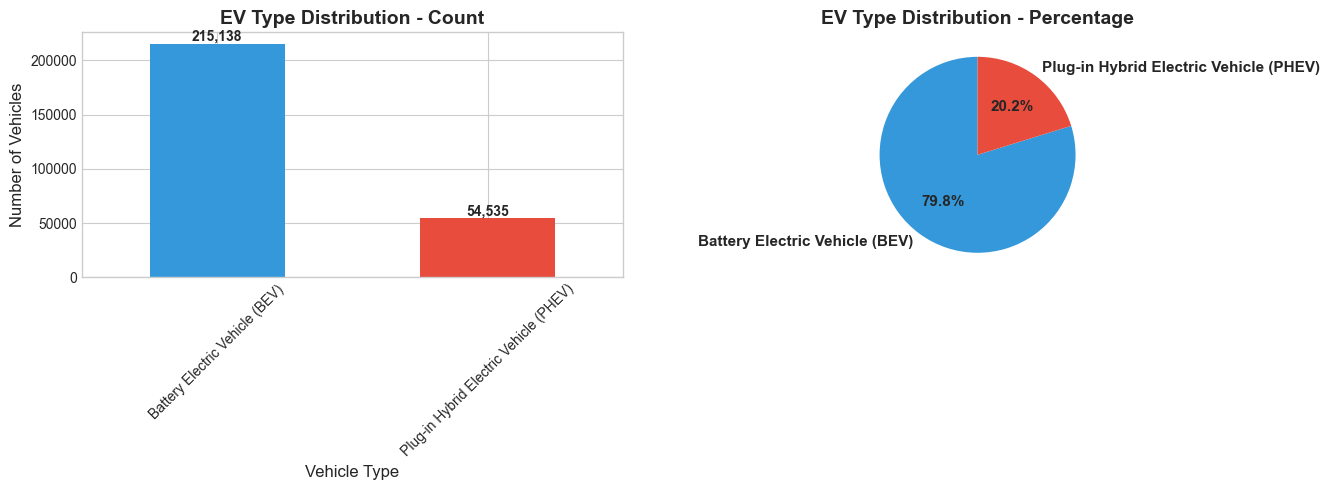

In [ ]:
# Adjust column name based on actual dataset
ev_type_col = [col for col in df.columns if 'type' in col.lower()]
if ev_type_col:
    ev_type_col = ev_type_col[0]
    
    print("=" * 70)
    print("ELECTRIC VEHICLE TYPE DISTRIBUTION")
    print("=" * 70)
    
    type_counts = df[ev_type_col].value_counts()
    type_percent = df[ev_type_col].value_counts(normalize=True) * 100
    
    type_df = pd.DataFrame({
        'Count': type_counts,
        'Percentage': type_percent
    })
    print(type_df)
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    type_counts.plot(kind='bar', ax=ax1, color=['#3498db', '#e74c3c'])
    ax1.set_title('EV Type Distribution - Count', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Vehicle Type', fontsize=12)
    ax1.set_ylabel('Number of Vehicles', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    
    # Add value labels
    for i, v in enumerate(type_counts):
        ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
    
    # Pie chart
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
    type_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=colors[:len(type_counts)],
                     startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
    ax2.set_title('EV Type Distribution - Percentage', fontsize=14, fontweight='bold')
    ax2.set_ylabel('')
    
    plt.tight_layout()
    plt.show()
else:
    print("EV Type column not found")

### Top Electric Vehicle Makes

TOP 10 ELECTRIC VEHICLE MAKES
Make
TESLA         110635
CHEVROLET      19106
NISSAN         16103
FORD           14772
KIA            13479
TOYOTA         11139
BMW            11021
HYUNDAI         9609
RIVIAN          8343
VOLKSWAGEN      7345
Name: count, dtype: int64


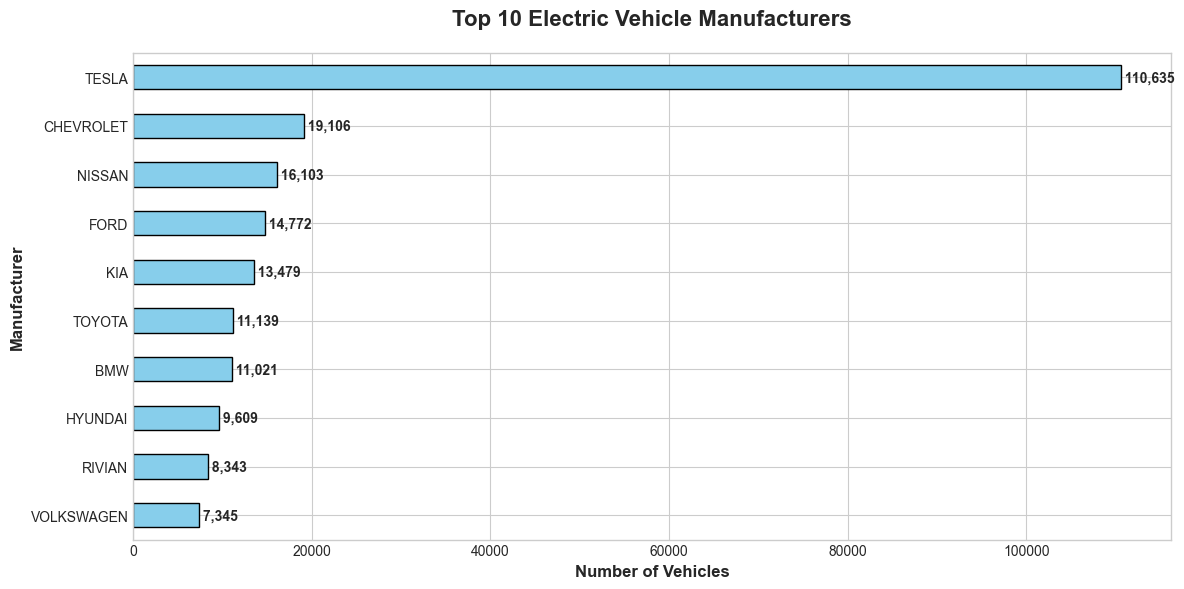

In [22]:
# Analyze top EV makes
make_col = [col for col in df.columns if 'make' in col.lower()]
if make_col:
    make_col = make_col[0]
    
    print("=" * 70)
    print("TOP 10 ELECTRIC VEHICLE MAKES")
    print("=" * 70)
    
    top_makes = df[make_col].value_counts().head(10)
    print(top_makes)
    
    # Visualization
    plt.figure(figsize=(12, 6))
    ax = top_makes.plot(kind='barh', color='skyblue', edgecolor='black')
    plt.title('Top 10 Electric Vehicle Manufacturers', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Number of Vehicles', fontsize=12, fontweight='bold')
    plt.ylabel('Manufacturer', fontsize=12, fontweight='bold')
    plt.gca().invert_yaxis()
    
    # Add value labels
    for i, v in enumerate(top_makes):
        plt.text(v, i, f' {v:,}', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("Make column not found")

### Top Electric Vehicle Models

TOP 15 ELECTRIC VEHICLE MODELS
Model Year
2023    60085
2024    49200
2025    35520
2022    29627
2021    20701
2018    14179
2020    12154
2019    10915
2026     9693
2017     8577
2016     5166
2015     4470
2013     4033
2014     3263
2012     1425
Name: count, dtype: int64


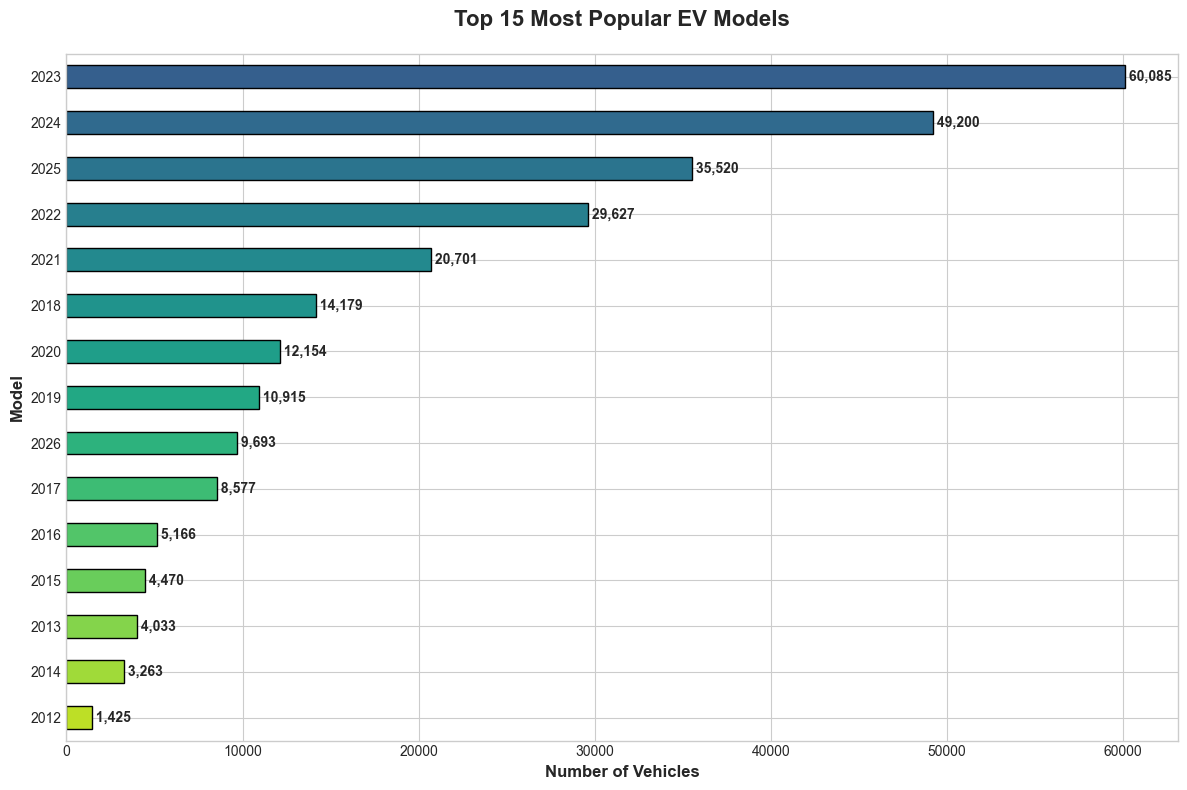

In [23]:
# Analyze top EV models
model_col = [col for col in df.columns if 'model' in col.lower()]
if model_col:
    model_col = model_col[0]
    
    print("=" * 70)
    print("TOP 15 ELECTRIC VEHICLE MODELS")
    print("=" * 70)
    
    top_models = df[model_col].value_counts().head(15)
    print(top_models)
    
    # Visualization
    plt.figure(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_models)))
    top_models.plot(kind='barh', color=colors, edgecolor='black')
    plt.title('Top 15 Most Popular EV Models', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Number of Vehicles', fontsize=12, fontweight='bold')
    plt.ylabel('Model', fontsize=12, fontweight='bold')
    plt.gca().invert_yaxis()
    
    # Add value labels
    for i, v in enumerate(top_models):
        plt.text(v, i, f' {v:,}', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("Model column not found")

### Model Year Analysis

EV REGISTRATION BY MODEL YEAR
Year Range: 1999 - 2026

Top 5 Years:
Model Year
2023    60085
2024    49200
2025    35520
2022    29627
2021    20701
Name: count, dtype: int64


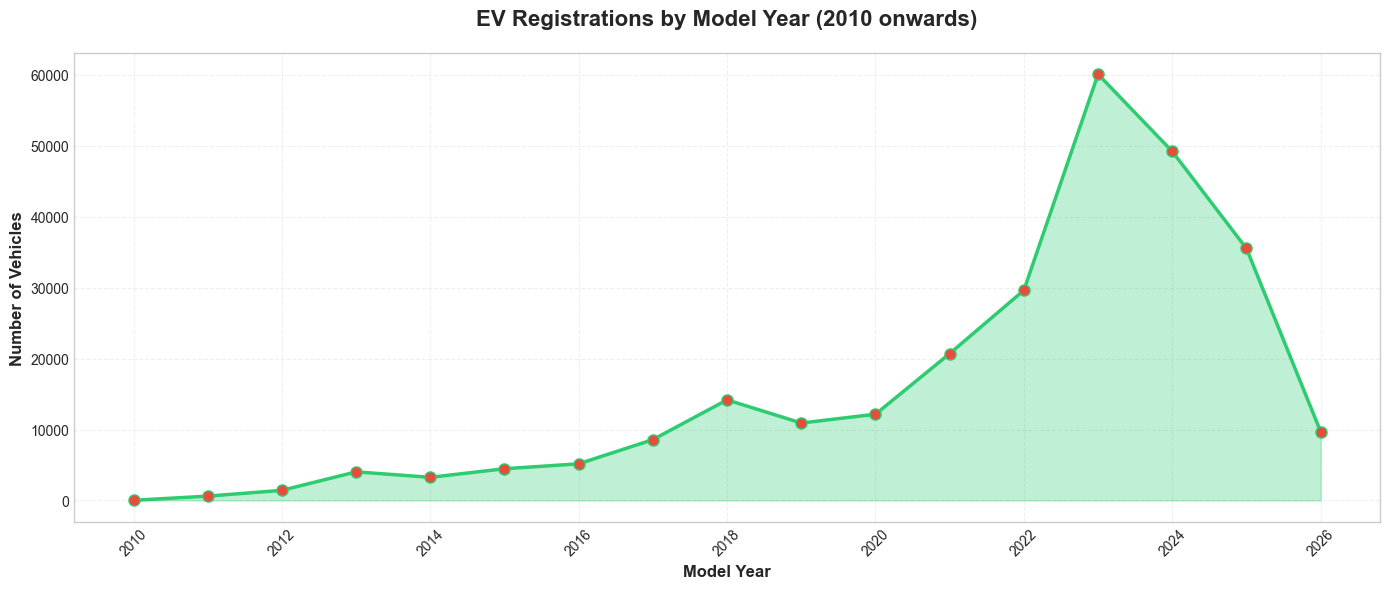

In [ ]:
# Analyze model years
year_col = [col for col in df.columns if 'year' in col.lower()]
if year_col:
    year_col = year_col[0]
    
    print("=" * 70)
    print("EV REGISTRATION BY MODEL YEAR")
    print("=" * 70)
    
    year_counts = df[year_col].value_counts().sort_index()
    print(f"Year Range: {year_counts.index.min()} - {year_counts.index.max()}")
    print(f"\nTop 5 Years:")
    print(df[year_col].value_counts().head())
    
    # Visualization
    recent_years = year_counts[year_counts.index >= 2010]
    
    plt.figure(figsize=(14, 6))
    plt.plot(recent_years.index, recent_years.values, marker='o', linewidth=2.5, 
             markersize=8, color='#2ecc71', markerfacecolor='#e74c3c')
    plt.fill_between(recent_years.index, recent_years.values, alpha=0.3, color='#2ecc71')
    
    plt.title('EV Registrations by Model Year (2010 onwards)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Model Year', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Vehicles', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print("Year column not found")

### Electric Range Analysis

ELECTRIC RANGE STATISTICS
Average Range: 108.88 miles
Median Range: 53.00 miles
Maximum Range: 337.00 miles
Minimum Range: 1.00 miles
Standard Deviation: 97.53 miles


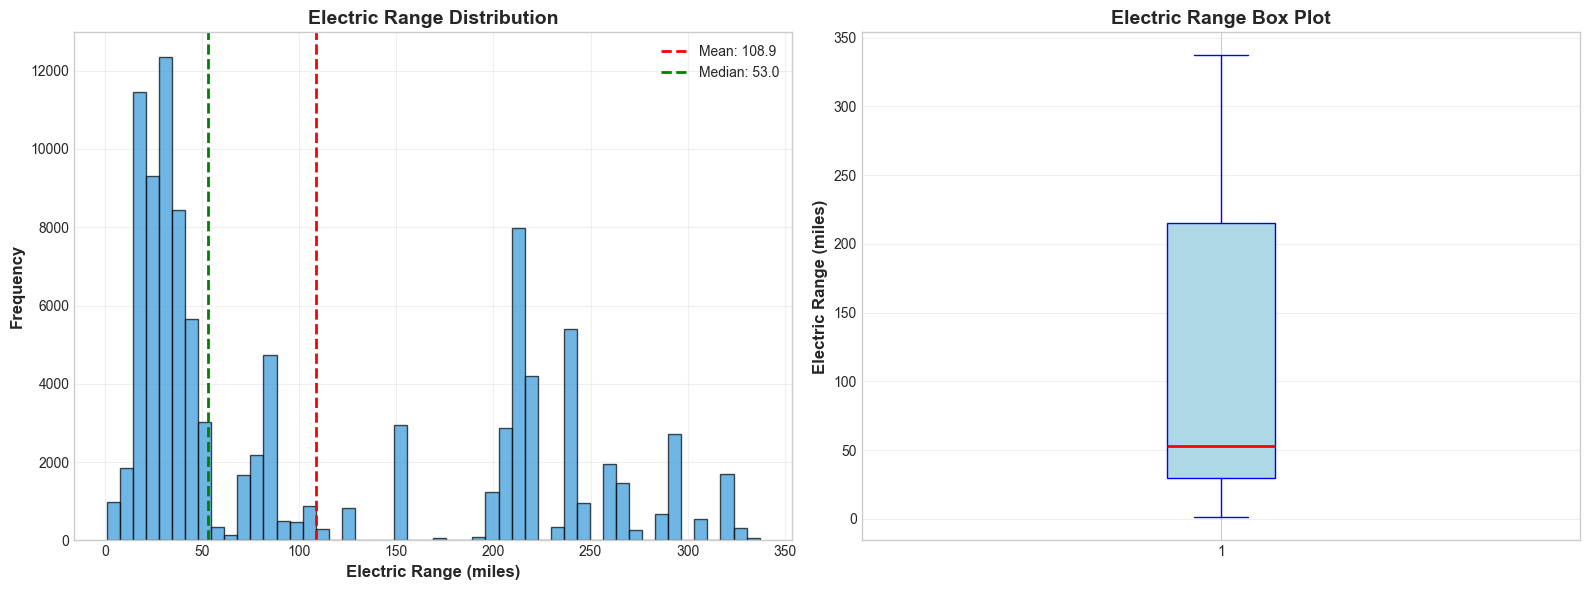

In [25]:
# Analyze electric range
range_col = [col for col in df.columns if 'range' in col.lower()]
if range_col:
    range_col = range_col[0]
    
    # Clean data - remove zeros and convert to numeric
    df[range_col] = pd.to_numeric(df[range_col], errors='coerce')
    range_data = df[df[range_col] > 0][range_col]
    
    print("=" * 70)
    print("ELECTRIC RANGE STATISTICS")
    print("=" * 70)
    print(f"Average Range: {range_data.mean():.2f} miles")
    print(f"Median Range: {range_data.median():.2f} miles")
    print(f"Maximum Range: {range_data.max():.2f} miles")
    print(f"Minimum Range: {range_data.min():.2f} miles")
    print(f"Standard Deviation: {range_data.std():.2f} miles")
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Histogram
    ax1.hist(range_data, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
    ax1.axvline(range_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {range_data.mean():.1f}')
    ax1.axvline(range_data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {range_data.median():.1f}')
    ax1.set_title('Electric Range Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Electric Range (miles)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Box plot
    ax2.boxplot(range_data, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='blue'),
                whiskerprops=dict(color='blue'),
                capprops=dict(color='blue'),
                medianprops=dict(color='red', linewidth=2))
    ax2.set_title('Electric Range Box Plot', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Electric Range (miles)', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("Range column not found")

### Geographic Distribution

TOP 10 COUNTIES BY EV POPULATION
County
King         133634
Snohomish     33412
Pierce        22256
Clark         16543
Thurston       9847
Kitsap         9045
Spokane        7586
Whatcom        6570
Benton         3724
Skagit         3188
Name: count, dtype: int64


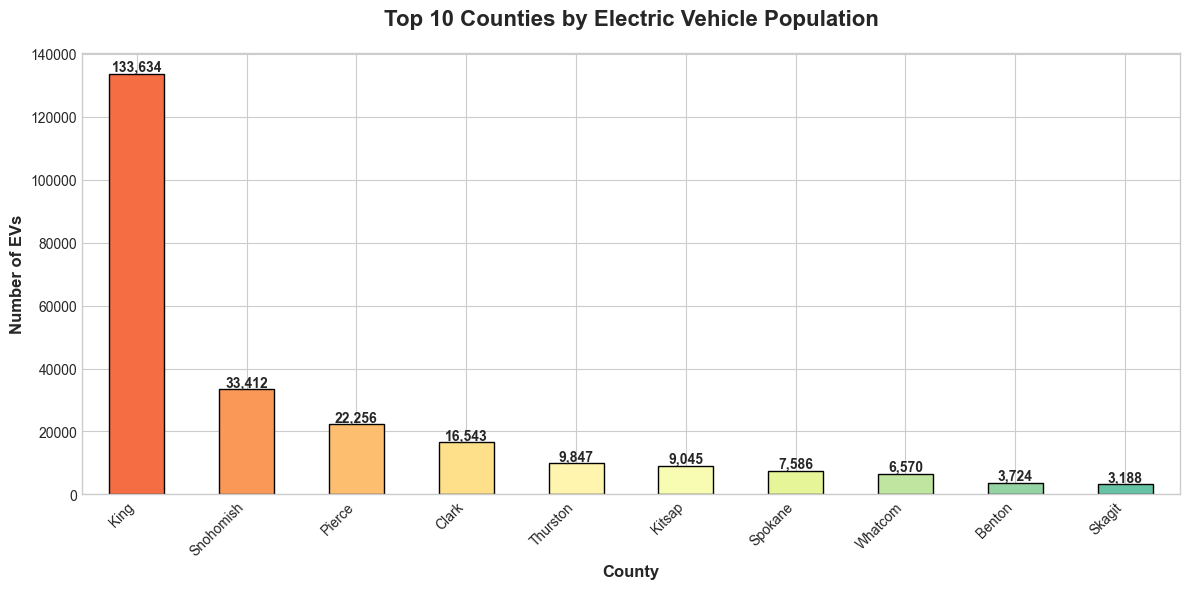


TOP 15 CITIES BY EV POPULATION
City
Seattle       42191
Bellevue      13128
Vancouver     10038
Redmond        9286
Bothell        8911
Kirkland       7635
Sammamish      7506
Renton         7391
Olympia        6342
Tacoma         5939
Kent           4562
Spokane        4503
Bellingham     4457
Lynnwood       4390
Everett        4269
Name: count, dtype: int64


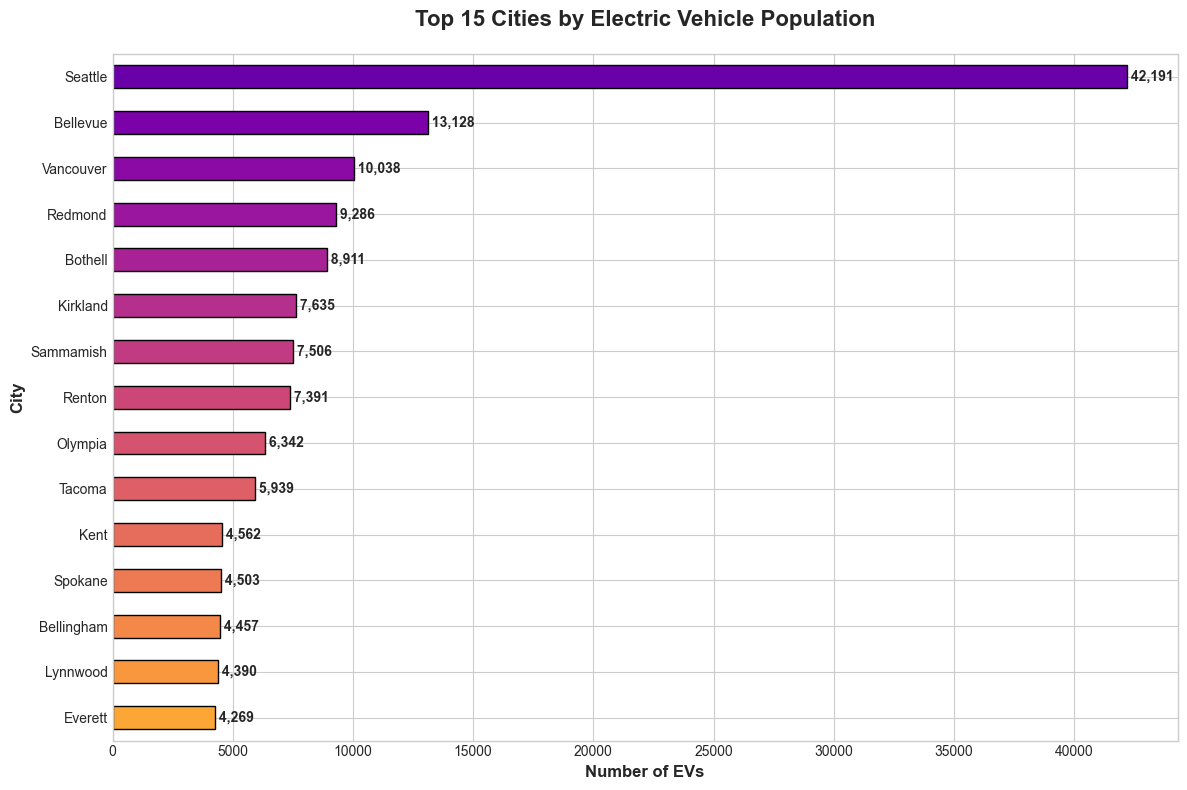

In [26]:
# Analyze geographic distribution
county_col = [col for col in df.columns if 'county' in col.lower()]
city_col = [col for col in df.columns if 'city' in col.lower()]

if county_col:
    county_col = county_col[0]
    
    print("=" * 70)
    print("TOP 10 COUNTIES BY EV POPULATION")
    print("=" * 70)
    
    top_counties = df[county_col].value_counts().head(10)
    print(top_counties)
    
    # Visualization
    plt.figure(figsize=(12, 6))
    colors = plt.cm.Spectral(np.linspace(0.2, 0.8, len(top_counties)))
    top_counties.plot(kind='bar', color=colors, edgecolor='black')
    plt.title('Top 10 Counties by Electric Vehicle Population', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('County', fontsize=12, fontweight='bold')
    plt.ylabel('Number of EVs', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels
    for i, v in enumerate(top_counties):
        plt.text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

if city_col:
    city_col = city_col[0]
    
    print("\n" + "=" * 70)
    print("TOP 15 CITIES BY EV POPULATION")
    print("=" * 70)
    
    top_cities = df[city_col].value_counts().head(15)
    print(top_cities)
    
    # Visualization
    plt.figure(figsize=(12, 8))
    colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(top_cities)))
    top_cities.plot(kind='barh', color=colors, edgecolor='black')
    plt.title('Top 15 Cities by Electric Vehicle Population', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Number of EVs', fontsize=12, fontweight='bold')
    plt.ylabel('City', fontsize=12, fontweight='bold')
    plt.gca().invert_yaxis()
    
    # Add value labels
    for i, v in enumerate(top_cities):
        plt.text(v, i, f' {v:,}', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

### CAFV Eligibility

CAFV ELIGIBILITY DISTRIBUTION
                                                     Count  Percentage
Clean Alternative Fuel Vehicle (CAFV) Eligibility                     
Eligibility unknown as battery range has not be...  168734   62.569853
Clean Alternative Fuel Vehicle Eligible              76726   28.451495
Not eligible due to low battery range                24213    8.978652


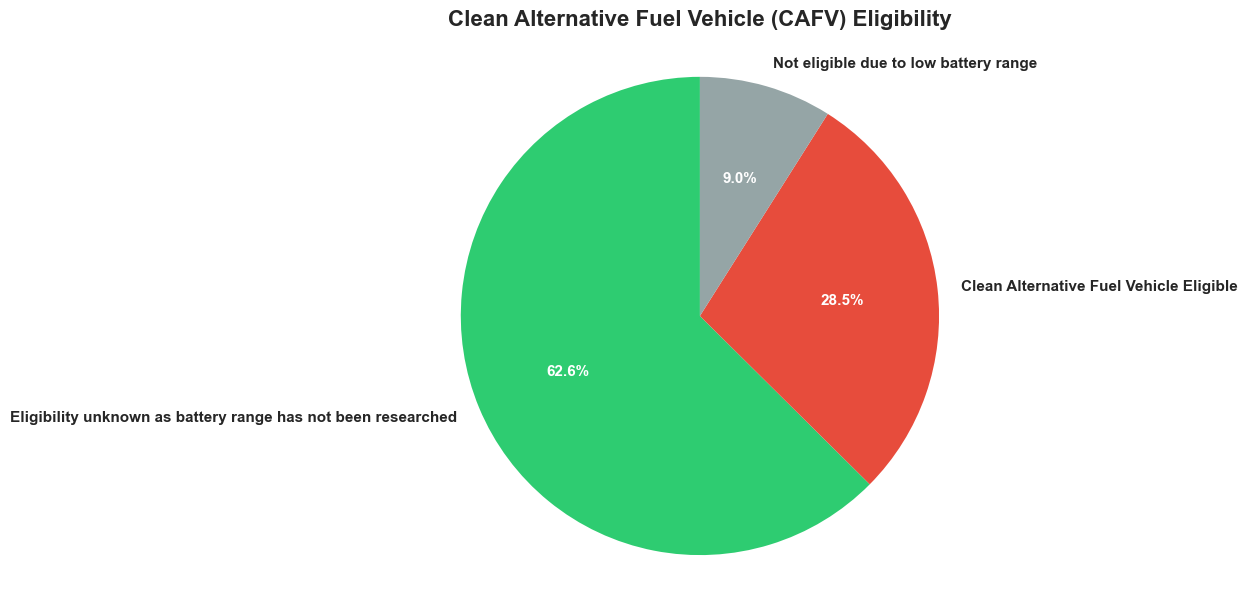

In [ ]:
# Analyze CAFV eligibility
cafv_col = [col for col in df.columns if 'cafv' in col.lower() or 'eligibility' in col.lower()]
if cafv_col:
    cafv_col = cafv_col[0]
    
    print("=" * 70)
    print("CAFV ELIGIBILITY DISTRIBUTION")
    print("=" * 70)
    
    cafv_counts = df[cafv_col].value_counts()
    cafv_percent = df[cafv_col].value_counts(normalize=True) * 100
    
    cafv_df = pd.DataFrame({
        'Count': cafv_counts,
        'Percentage': cafv_percent
    })
    print(cafv_df)
    
    # Visualization
    plt.figure(figsize=(12, 6))
    colors = ['#2ecc71', '#e74c3c', '#95a5a6', '#f39c12']
    wedges, texts, autotexts = plt.pie(cafv_counts, labels=cafv_counts.index, autopct='%1.1f%%',
                                        colors=colors[:len(cafv_counts)], startangle=90,
                                        textprops={'fontsize': 11, 'fontweight': 'bold'})
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    plt.title('Clean Alternative Fuel Vehicle (CAFV) Eligibility', fontsize=16, fontweight='bold', pad=20)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
else:
    print("CAFV eligibility column not found")

## Summary

In [ ]:
print("="*80)
print(" " * 20 + "ELECTRIC VEHICLE ANALYSIS SUMMARY")
print("="*80)

print(f"\nDATASET OVERVIEW")
print(f"Total EVs in Dataset: {len(df):,}")
print(f"Total Columns: {len(df.columns)}")

if ev_type_col:
    print(f"\nVEHICLE TYPES")
    for vtype, count in df[ev_type_col].value_counts().items():
        pct = (count/len(df))*100
        print(f"{vtype}: {count:,} ({pct:.1f}%)")

if make_col:
    top_make = df[make_col].value_counts().index[0]
    top_make_count = df[make_col].value_counts().values[0]
    print(f"\nTOP MANUFACTURER")
    print(f"{top_make}: {top_make_count:,} vehicles")

if model_col:
    top_model = df[model_col].value_counts().index[0]
    top_model_count = df[model_col].value_counts().values[0]
    print(f"\nMOST POPULAR MODEL")
    print(f"{top_model}: {top_model_count:,} vehicles")

if range_col:
    range_data = df[df[range_col] > 0][range_col]
    print(f"\nELECTRIC RANGE")
    print(f"Average: {range_data.mean():.1f} miles")
    print(f"Maximum: {range_data.max():.1f} miles")

if county_col:
    top_county = df[county_col].value_counts().index[0]
    top_county_count = df[county_col].value_counts().values[0]
    print(f"\nTOP LOCATION")
    print(f"{top_county} County: {top_county_count:,} vehicles")

if year_col:
    most_common_year = df[year_col].value_counts().index[0]
    print(f"\nMOST COMMON MODEL YEAR")
    print(f"{most_common_year}")

print("\n" + "="*80)
print("KEY FINDINGS:")
print("1. EV adoption growing year over year")
print("2. BEVs dominate the market")
print("3. Tesla is the leading manufacturer")
print("4. Higher adoption in urban areas")
print("5. Electric range improving with newer models")
print("6. Most vehicles qualify for clean energy incentives")
print("="*80)

                    ELECTRIC VEHICLE ANALYSIS SUMMARY

DATASET OVERVIEW
Total EVs in Dataset: 269,673
Total Columns: 17

VEHICLE TYPES
Battery Electric Vehicle (BEV): 215,138 (79.8%)
Plug-in Hybrid Electric Vehicle (PHEV): 54,535 (20.2%)

TOP MANUFACTURER
TESLA: 110,635 vehicles

MOST POPULAR MODEL
2023: 60,085 vehicles

ELECTRIC RANGE
Average: 108.9 miles
Maximum: 337.0 miles

TOP LOCATION
King County: 133,634 vehicles

MOST COMMON MODEL YEAR
2023

KEY FINDINGS:
1. EV adoption growing year over year
2. BEVs dominate the market
3. Tesla is the leading manufacturer
4. Higher adoption in urban areas
5. Electric range improving with newer models
6. Most vehicles qualify for clean energy incentives

TOP MANUFACTURER
TESLA: 110,635 vehicles

MOST POPULAR MODEL
2023: 60,085 vehicles

ELECTRIC RANGE
Average: 108.9 miles
Maximum: 337.0 miles

TOP LOCATION
King County: 133,634 vehicles

MOST COMMON MODEL YEAR
2023

KEY FINDINGS:
1. EV adoption growing year over year
2. BEVs dominate the market


## Conclusion

This project analyzed the Electric Vehicle Population dataset and found several patterns:

**Analysis Done:**
- Distribution of vehicle types (BEV vs PHEV)
- Manufacturer and model analysis
- Registration trends by year
- Geographic distribution (counties and cities)
- Electric range statistics

**Key Findings:**
1. BEVs are more common than PHEVs
2. Tesla is the leading manufacturer
3. Urban areas have more EV adoption
4. Electric range is improving
5. Most vehicles qualify for clean energy incentives

**What I Learned:**
- Using pandas for data analysis
- Creating visualizations with matplotlib and seaborn
- Statistical analysis and finding patterns
- Data cleaning and handling missing values

---

**Repository:** [EV-Population-Analysis](https://github.com/abhiyashthakur/EV-Population-Analysis)